# TP53 variant distribution and analysis

This code generates most elements of figures 1 and 2. The age-prevalence graph requires a UKB file that is not currently available, the remainder of the code can be run without this file. 

In [44]:
import os
import networkx as nx
import subprocess
import random
from pathlib import Path
import scipy.stats as stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import itertools

import matplotlib
matplotlib.rc_file_defaults()
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Lato'

print('matplotlib', matplotlib.__version__)
print('pandas', pd.__version__)
print('numpy', np.__version__)
print('networkx', nx.__version__)

matplotlib 3.8.2
pandas 2.1.3
numpy 1.26.2
networkx 3.4.2


### Import data

List of UKB tp53 variants with classification (non-individualised, does not require UKB access)

In [50]:
ukb_tp53_all = pd.read_csv('public_data/ukb_tp53_all_variants_redacted.tsv', sep='\t')

Ages and phenotype info for all UKB individuals (requires UKB access, not currently available)

In [51]:
# import UKB phenotypic file containing cancer, smoking and BMI records (only used here for 
biobank_cancer_smoking_bmi = pd.read_csv('data/biobank_pheno_cancer_smoking_BMI_select_columns_updated_2025_reclassified.tsv', sep='\t')

In [52]:
ukb_tp53_plp = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['Pathogenic', 'Likely_Pathogenic'])]
ukb_tp53_blb = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['Benign', 'Likely_Benign'])]
ukb_tp53_syn = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['Synonymous'])]
ukb_tp53_vus = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['VUS'])]
ukb_tp53_mna = ukb_tp53_all[ukb_tp53_all.Classification_by_multifactorial_model.isin(['Model_not_applied'])]

Fig. 1b: age distribution - requires UKB dataset access

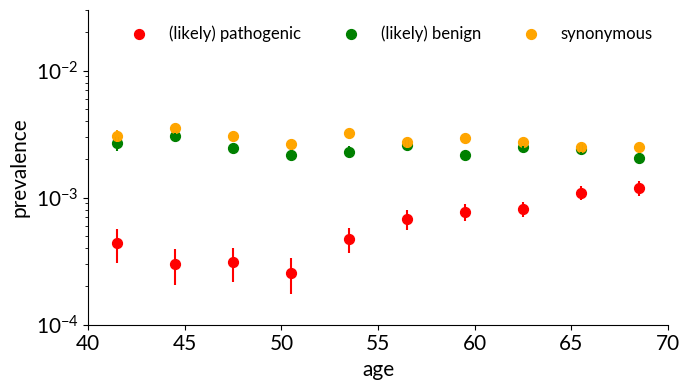

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

def hist_plot(ax, ages, bins, colour, label):
    hist = np.histogram(ages, bins=bins)
    pheno_hist = np.histogram(biobank_cancer_smoking_bmi['Age.when.attended.assessment.centre_v0'], bins=bins)
    bin_centres = (bins[1:] + bins[:-1])/2
    ax.scatter(bin_centres, hist[0]/pheno_hist[0], color=colour, s=50, label=label)
    ax.errorbar(bin_centres, hist[0]/pheno_hist[0], np.sqrt(hist[0])/pheno_hist[0], ls='none', color=colour)

bins=np.arange(40, 73, 3)
hist_plot(ax, ukb_tp53_plp['Age.when.attended.assessment.centre_v0'], bins, 'red', '(likely) pathogenic')

bins=np.arange(40, 73, 3)
hist_plot(ax, ukb_tp53_blb['Age.when.attended.assessment.centre_v0'], bins, 'green', '(likely) benign')

bins=np.arange(40, 73, 3)
hist_plot(ax, ukb_tp53_syn['Age.when.attended.assessment.centre_v0'], bins, 'orange', 'synonymous')


ax.set_yscale('log')
ax.set_ylim(1e-4, 3e-2)
ax.set_xlim(40, 70)
ax.set_ylabel('prevalence')
ax.set_xlabel('age')
ax.legend(ncol=3, fontsize=12)

plt.tight_layout()
#plt.savefig('../Thesis files/figures_TP53/TP53_prevalences.pdf')
plt.show()

Fig. 1d: VAF distribution

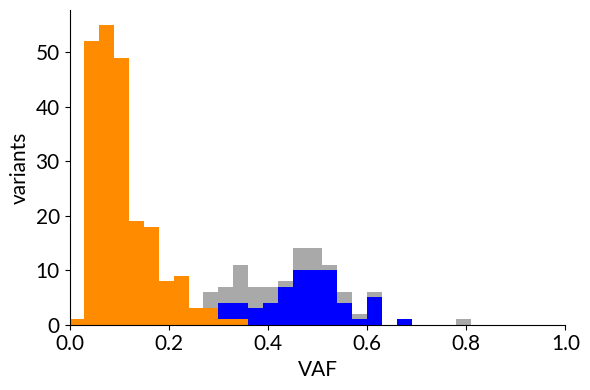

In [54]:
fig, ax = plt.subplots(1, 1, figsize=[6,4])
ax.hist([ukb_tp53_plp[ukb_tp53_plp['germ_likelihood'] == 'unlikely'].VAF,
         ukb_tp53_plp[ukb_tp53_plp['germ_likelihood'] == 'likely'].VAF,
         ukb_tp53_plp[ukb_tp53_plp['germ_likelihood'] == 'inconclusive'].VAF], bins=np.arange(0, 1, 0.03), stacked=True, color=['darkorange', 'blue', 'darkgrey'])

ax.set_xlim(0, 1)
ax.set_ylabel('variants')
ax.set_xlabel('VAF')
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/TP53_VAF_distribution.png', transparent=True, dpi=300)
plt.show()

In [17]:
def calculate_germline_binomial_pdf(df, mean_VAF, depth_binwidth, x_range):

    # binned depth
    depth_hist, depth_bins = np.histogram(df.depth, bins=np.arange(18, 122, depth_binwidth))
    mid_depth_bins = [i + 0.5*depth_binwidth for i in depth_bins[:-1]]

    germline_dist_by_depth = {}
    germline_freq_by_depth = {}
    for depth in mid_depth_bins:
        i= mid_depth_bins.index(depth)
        weight = depth_hist[i]#/sum(depth_hist)
        germline_freq_by_depth[depth] = np.arange(depth+1)/depth
        germline_dist_by_depth[depth] = stats.binom.pmf(np.arange(depth+1), depth, mean_VAF) * weight # currently not thinking too much about what that means for the overall area

    # depth-adjusted distribution
    germline_distribution = np.zeros(len(x_range))
    for depth in mid_depth_bins:
        increment = np.interp(x_range, germline_freq_by_depth[depth], germline_dist_by_depth[depth])
        germline_distribution += increment
    # normalise
    germline_distribution = germline_distribution/sum(germline_distribution)/np.diff(x_range)[0]
    return germline_distribution

Supplementary Fig. 1: Binomial VAF distributions for benign and synonymous variants

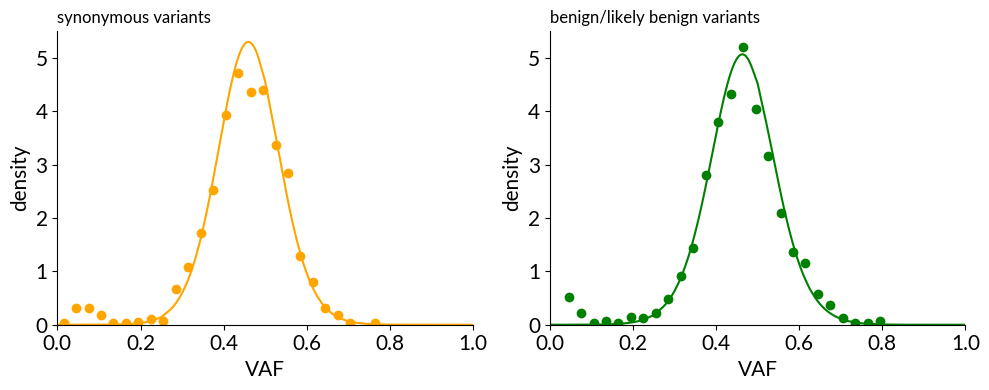

In [18]:
# theoretical:

depth_binwidth=4
x = np.arange(1001)/1000

ukb_tp53_syn_central = ukb_tp53_syn[(ukb_tp53_syn.VAF > 0.2)]
synonymous_mean_VAF = ukb_tp53_syn_central.VAF.mean()

syn_germline_distribution = calculate_germline_binomial_pdf(ukb_tp53_syn, synonymous_mean_VAF, depth_binwidth, x)

ukb_tp53_blb_central = ukb_tp53_blb[(ukb_tp53_blb.VAF > 0.2)]
benign_mean_VAF = ukb_tp53_blb_central.VAF.mean()

blb_germline_distribution = calculate_germline_binomial_pdf(ukb_tp53_blb, benign_mean_VAF, depth_binwidth, x)

fig, ax = plt.subplots(1, 2, figsize=[10, 4])

# synonymous
ax[0].plot(x, syn_germline_distribution, label='using depth distribution', color='orange')
hist, bins = np.histogram(ukb_tp53_syn.VAF, bins = np.arange(0, 1, 0.03), density=True)
bin_centres = 0.5*(bins[1:]+bins[:-1])
ax[0].scatter(bin_centres, np.where(hist == 0, -1, hist), color='orange')
ax[0].set_title('synonymous variants', loc='left')
ax[0].set_xlabel('VAF')
ax[0].set_ylabel("density")
ax[0].set_ylim(0, 5.5)
ax[0].set_xlim(0, 1)

ax[1].plot(x, blb_germline_distribution, label='using depth distribution', color='green')
hist, bins = np.histogram(ukb_tp53_blb.VAF, bins = np.arange(0, 1, 0.03), density=True)
bin_centres = 0.5*(bins[1:]+bins[:-1])
ax[1].scatter(bin_centres, np.where(hist == 0, -1, hist), color='green')
ax[1].set_title('benign/likely benign variants', loc='left')
ax[1].set_xlabel('VAF')
ax[1].set_ylabel("density")
ax[1].set_ylim(0, 5.5)
ax[1].set_xlim(0, 1)

plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/binomial_distributions_synonymous_benign.pdf')

### Distributions of TP53 variants

Fig. 2a: distribution of pathogenic TP53 variants

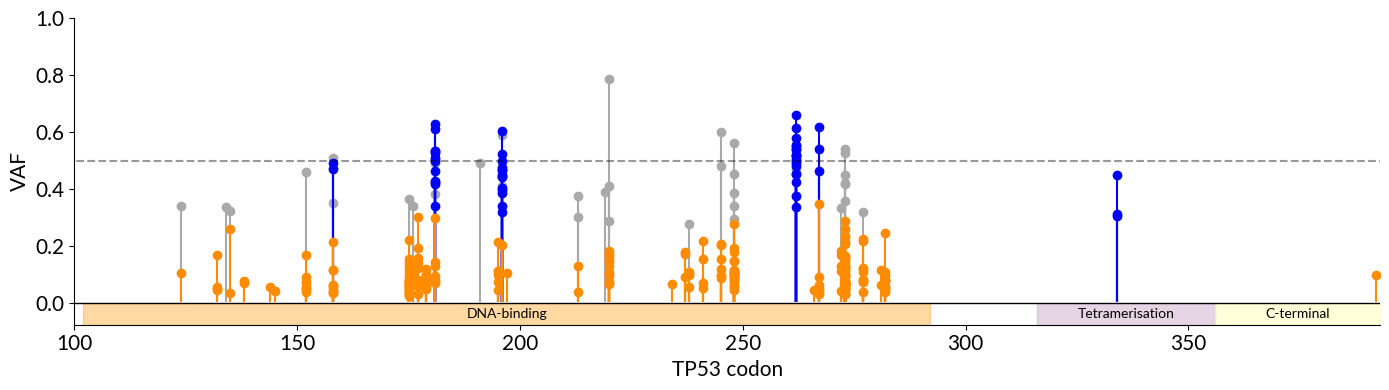

In [19]:
# traditional stem plot
def stemplot(axes, data, colour):
    m, s, b = axes.stem(data.Protein_position.astype('int'), data.VAF, linefmt=colour, markerfmt='o', basefmt='white', label='synonymous')
    plt.setp(m, 'color', colour)
    return

fig, ax = plt.subplots(1, 1, figsize=[14, 4])
stemplot(ax, ukb_tp53_plp[ukb_tp53_plp['germ_likelihood'] == 'inconclusive'], 'darkgrey')
stemplot(ax, ukb_tp53_plp[ukb_tp53_plp['germ_likelihood'] == 'likely'], 'blue')
stemplot(ax, ukb_tp53_plp[ukb_tp53_plp['germ_likelihood'] == 'unlikely'], 'darkorange')


ax.hlines(0, 0, 394, color='k', lw=1)
ax.hlines(0.5, 0, 394, color='k', ls='dashed', alpha=0.4)

tp53_domains = {
    "Transactivation": (0, 63, "#aec6cf"),  # Medium peach
    "Proline-rich": (63, 92, "#baffc9"),   # Medium blue
    "DNA-binding": (102, 292, "#ffb347"),  # Medium green
    "Tetramerisation": (316, 356, "#cbaacb"),  # Medium purple
    "C-terminal": (356, 393, "#ffffb3")  # Medium golden yellow
}

xlims = (100, 393)
for name, (start, end, colour) in tp53_domains.items():

    ax.fill_between([start, end], -0.075, 0, alpha=0.5, color=colour)
    if (0.5*(start+end) > xlims[0]) & (0.5*(start+end) < xlims[1]):
        ax.text(0.5*(start+end), -0.0375, name, va='center', ha='center', size=10)
#ax.fill_between([102, 292], -0.2, 0, alpha=0.5, color="#99D6A2")
#ax.text(190, -0.075, 'DNA binding domain', va='center', size=12)

ax.set_xlim(xlims)
ax.set_ylim(-0.075, 1)
ax.set_xlabel('TP53 codon')
ax.set_ylabel('VAF')
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/stemplot_classified.pdf')

Fig. 2c: distribution of 'Model not applied' variants

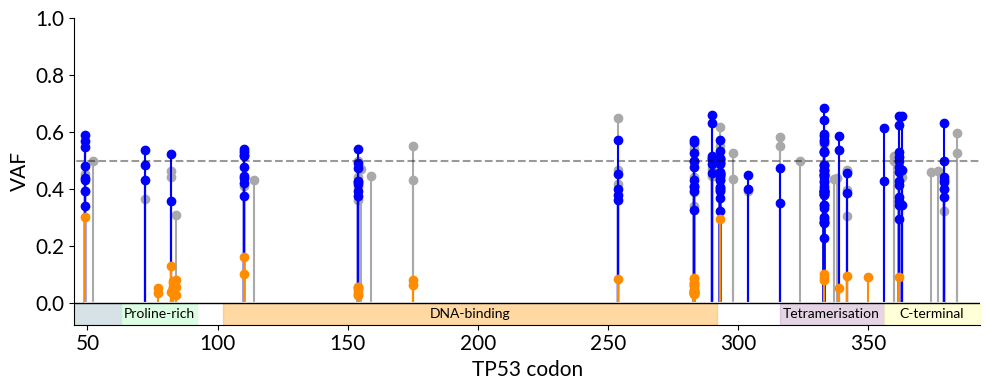

In [28]:
# traditional stem plot - 'model not applied' variants


def stemplot(axes, data, colour):
    m, s, b = axes.stem(data.Protein_position.astype('int'), data.VAF, linefmt=colour, markerfmt='o', basefmt='white',
                        label='synonymous')
    plt.setp(m, 'color', colour)
    return


fig, ax = plt.subplots(1, 1, figsize=[10, 4])
stemplot(ax, ukb_tp53_mna[ukb_tp53_mna['germ_likelihood'] == 'inconclusive'], 'darkgrey')
stemplot(ax, ukb_tp53_mna[ukb_tp53_mna['germ_likelihood'] == 'likely'], 'blue')
stemplot(ax, ukb_tp53_mna[ukb_tp53_mna['germ_likelihood'] == 'unlikely'], 'darkorange')

ax.hlines(0, 0, 394, color='k', lw=1)
ax.hlines(0.5, 0, 394, color='k', ls='dashed', alpha=0.4)

tp53_domains = {
    "Transactivation": (0, 63, "#aec6cf"),  # Medium peach
    "Proline-rich": (63, 92, "#baffc9"),  # Medium blue
    "DNA-binding": (102, 292, "#ffb347"),  # Medium green
    "Tetramerisation": (316, 356, "#cbaacb"),  # Medium purple
    "C-terminal": (356, 393, "#ffffb3")  # Medium golden yellow
}

xlims = (45, 393)
for name, (start, end, colour) in tp53_domains.items():

    ax.fill_between([start, end], -0.075, 0, alpha=0.5, color=colour)
    if (0.5 * (start + end) > xlims[0]) & (0.5 * (start + end) < xlims[1]):
        ax.text(0.5 * (start + end), -0.0375, name, va='center', ha='center', size=10)
#ax.fill_between([102, 292], -0.2, 0, alpha=0.5, color="#99D6A2")
#ax.text(190, -0.075, 'DNA binding domain', va='center', size=12)

ax.set_xlim(xlims)
ax.set_ylim(-0.075, 1)
ax.set_xlabel('TP53 codon')
ax.set_ylabel('VAF')
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/stemplot_classified_model_not_applied_all.pdf')

### Fig. 2b: comparison with TP53 database

In [37]:
pwd

'/Users/hamish/Documents/!Hamish MacGregor/Cambridge/PhD/TP53/TP53_manuscript/code_repo'

In [38]:
# tp53-db: all recorded germline variants

tp53_db_germline = pd.read_csv('data/GermlineDownload_r21.csv')
fortuno_pathogenicity = pd.read_csv('data/fortuno_all_variant_pathogenicity.csv')
fortuno_pathogenicity = fortuno_pathogenicity.drop_duplicates('Protein_change_abbreviated_NP_000537_3')
# drop duplicates in fortuno-pathogenicity amino acid substitutions. be careful with this, as this removes some degeneracy in cDNA substitutions, so the dataset can't be used for this now. However, there shoudl eb no functional difference

# attach description
tp53_db_germline = pd.merge(tp53_db_germline, fortuno_pathogenicity[['Protein_change_abbreviated_NP_000537_3', 'Classification_by_multifactorial_model']].rename(columns={'Protein_change_abbreviated_NP_000537_3':'ProtDescription'}), how='left', on='ProtDescription')
print(len(tp53_db_germline), 'all TP53-db')
# SNV only
#pattern = r'^p\.[A-Z][0-9]+[A-Z]$'

tp53_db_missense = tp53_db_germline[tp53_db_germline.Effect == 'missense'].copy()

tp53_db_missense['codon'] = tp53_db_missense['ProtDescription'].str[3:-1].astype(int)
print(len(tp53_db_missense), 'missense only')

4649 all TP53-db
3233 missense only


In [24]:
# drop duplicates in 'Family ID' to ensure we record only one count per LFS family
tp53_db_variant_counts = tp53_db_germline.drop_duplicates('Family_ID').value_counts('ProtDescription').reset_index().rename(columns={'count':'n_tp53db'})
ukb_tp53_variant_counts = ukb_tp53_all.value_counts('Protein_change_abbreviated_P04637').reset_index().rename(columns={'count':'n_ukb', 'Protein_change_abbreviated_P04637':'ProtDescription'})
ukb_tp53_variant_counts['ProtDescription'] = 'p.'+ ukb_tp53_variant_counts['ProtDescription']


In [25]:

variant_compare = pd.merge(tp53_db_variant_counts, ukb_tp53_variant_counts, how='outer', on='ProtDescription')
variant_compare = pd.merge(variant_compare, fortuno_pathogenicity[['Protein_change_abbreviated_NP_000537_3', 'Classification_by_multifactorial_model']].rename(columns={'Protein_change_abbreviated_NP_000537_3':'ProtDescription'}), how='left', on='ProtDescription')
variant_compare.loc[variant_compare.ProtDescription.str[2] == variant_compare.ProtDescription.str[-1], 'Classification_by_multifactorial_model'] = 'Synonymous'
variant_compare.loc[variant_compare.ProtDescription.str[-1] == '?', 'Classification_by_multifactorial_model'] = np.NaN
variant_compare.loc[variant_compare.ProtDescription.str[-1] == '*', 'Classification_by_multifactorial_model'] = 'Truncating'
variant_compare.loc[variant_compare.ProtDescription.str[-2:] == 'fs', 'Classification_by_multifactorial_model'] = 'Frameshift'
variant_compare = variant_compare[variant_compare.ProtDescription.str[-1] != '?'].reset_index(drop=True)

# remove 9 inframe deletions and insertions. These are never seen in UKB
variant_compare = variant_compare[variant_compare.Classification_by_multifactorial_model == variant_compare.Classification_by_multifactorial_model].reset_index(drop=True)

variant_compare['codon'] = variant_compare.ProtDescription.str.extract(r"p\.[A-Za-z]+(\d+)[A-Za-z*]+").astype(int)

In [26]:
variant_compare

,ProtDescription,n_tp53db,n_ukb,Classification_by_multifactorial_model,codon
0,p.R337H,120.0,1.0,Model_not_applied,337
1,p.R175H,60.0,27.0,Pathogenic,175
2,p.R273H,53.0,32.0,Pathogenic,273
3,p.R248W,53.0,11.0,Pathogenic,248
4,p.R248Q,50.0,15.0,Pathogenic,248
...,...,...,...,...,...
523,p.G374C,NaN,1.0,Model_not_applied,374
524,p.D186N,NaN,1.0,Likely_Benign,186
525,p.P152P,NaN,1.0,Synonymous,152
526,p.P191L,NaN,1.0,Likely_Pathogenic,191


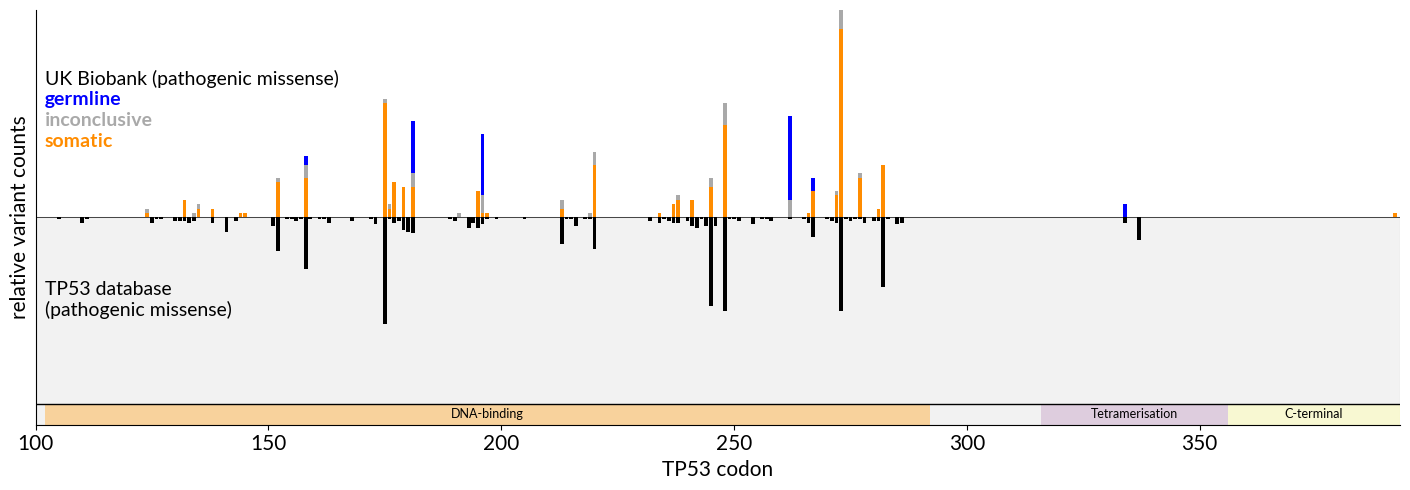

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(14.2, 5))
category_order = ['unlikely', 'inconclusive', 'likely']
vartype=['Pathogenic', 'Likely_Pathogenic']
df = ukb_tp53_plp.copy()
pivot = (df.groupby(['Protein_position', 'germ_likelihood']).size().unstack(fill_value=0))

cols = [c for c in category_order if c in pivot.columns]
pivot = pivot[cols]

def sort_key(v):
    try:
        return (0, int(v))
    except Exception:
        return (1, str(v))
pivot = pivot.reindex(sorted(pivot.index, key=sort_key))

bottoms = np.zeros(len(pivot))
x = pivot.index.values

colors = ['darkorange', 'darkgrey', 'blue']

for i, cat in enumerate(pivot.columns):
    ax.bar(x, pivot[cat]/315, bottom=bottoms, width=0.8,  # width=1 codon wide
           label=cat, color=colors[i % len(colors)], align="center")
    bottoms += pivot[cat].values/315



df = variant_compare[variant_compare.Classification_by_multifactorial_model.isin(vartype)]
ax.bar(df['codon'], -df['n_tp53db']/df['n_tp53db'].sum(), align='center', color='k')

ax.set_yticks([])
ax.set_ylabel('relative variant counts')
ax.set_xlabel('TP53 codon')

ax.set_xlim(0, 393)
ax.set_ylim(-0.15, 0.15)
ax.hlines(0, 0, 393, lw=0.5, color='k')
ax.text(102, -0.06, 'TP53 database\n(pathogenic missense)', ha='left', va='center', size=14, color='k')
ax.text(102, +0.10, 'UK Biobank (pathogenic missense)', ha='left', va='center', size=14, color='k')
ax.text(102, +0.085, 'germline', ha='left', va='center', size=14, color='blue', weight='bold')
ax.text(102, +0.07, 'inconclusive', ha='left', va='center', size=14, color='darkgrey', weight='bold')
ax.text(102, +0.055, 'somatic', ha='left', va='center', size=14, color='darkorange', weight='bold')

tp53_domains = [
    #("Transactivation",            1,   63,  "#aec6cf"),  # pastel blue
    #("Proline-rich",               63,  94,  "#baffc9"),   # pastel green
    ("DNA-binding",                102, 292,  "#ffb347"),   # pastel orange
    ("Tetramerisation",           316, 356,  "#cbaacb"),   # pastel purple
    ("C-terminal",                356, 393,  "#ffffb3"),   # pastel yellow
]

# y-position and height of the bar
bar_y = -0.15     # just above the x-axis baseline (adjust if needed)
bar_h = 0.015      # height of each domain patch
ax.hlines(bar_y+bar_h, 0, 393, color='k', lw=1, zorder=3)
for name, start, end, colour in tp53_domains:
    ax.add_patch(
        plt.Rectangle(
            (start, bar_y),             # (x, y) lower left corner
            end - start,                # width
            bar_h,                      # height
            facecolor=colour,
            edgecolor="none",
            alpha=0.5,
            zorder=2
        )
    )
    # Optionally add text label centred in the domain
    ax.text(
        (start + end) / 2, bar_y + bar_h - 0.0075,
        name, ha="center", va="center",
        fontsize=9, color="black"
    )

ax.fill_between([0, 393], [-0.15, -0.15], alpha=0.05, color='k')

ax.set_xlim(100, 393)
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/tp53_db_ukb_compare_normalised_crop.pdf')

plt.show()

### Proxy pathogenicity analysis (Fig. 2d)

In [30]:
vars_to_test_1plus = ukb_tp53_mna[ukb_tp53_mna.binomial_p_value < 0.01].value_counts('varID')
vars_to_test_1plus = list(vars_to_test_1plus.index)

# 1. at least one somatic variant in ukb; 2. all MNE non-somatic; 3. all MNE non-somatic seen in UKB
somatic_paths_1plus = fortuno_pathogenicity[fortuno_pathogenicity.Protein_change_abbreviated_P04637.isin(vars_to_test_1plus)].Posterior_probability_of_pathogenicity
somatic_paths_not_1plus_all = fortuno_pathogenicity[(~fortuno_pathogenicity.Protein_change_abbreviated_P04637.isin(vars_to_test_1plus)) & (fortuno_pathogenicity.Classification_by_multifactorial_model == 'Model_not_applied')].Posterior_probability_of_pathogenicity
somatic_paths_not_1plus_ukb = fortuno_pathogenicity[(~fortuno_pathogenicity.Protein_change_abbreviated_P04637.isin(vars_to_test_1plus)) & (fortuno_pathogenicity.Protein_change_abbreviated_P04637.isin(ukb_tp53_mna.varID.unique()))].Posterior_probability_of_pathogenicity

In [31]:
# restricting to DNA binding domain

ukb_tp53_mna_dbd = ukb_tp53_mna[(ukb_tp53_mna.Protein_position > 102) & (ukb_tp53_mna.Protein_position <= 292)]

fortuno_pathogenicity_dbd = fortuno_pathogenicity[(pd.to_numeric(fortuno_pathogenicity['Protein_change_abbreviated_P04637'].str.extract('(\d+)')[0], errors='coerce') > 102) &
                                                  (pd.to_numeric(fortuno_pathogenicity['Protein_change_abbreviated_P04637'].str.extract('(\d+)')[0], errors='coerce') <= 292)]


In [32]:
vars_to_test_1plus_dbd = ukb_tp53_mna_dbd[ukb_tp53_mna_dbd.binomial_p_value < 0.001].value_counts('varID')
vars_to_test_1plus_dbd = list(vars_to_test_1plus_dbd.index)

# 1. at least one somatic variant in ukb; 2. all MNE non-somatic; 3. all MNE non-somatic seen in UKB
somatic_paths_1plus_dbd = fortuno_pathogenicity_dbd[fortuno_pathogenicity_dbd.Protein_change_abbreviated_P04637.isin(vars_to_test_1plus_dbd)].Posterior_probability_of_pathogenicity
somatic_paths_not_1plus_all_dbd = fortuno_pathogenicity_dbd[(~fortuno_pathogenicity_dbd.Protein_change_abbreviated_P04637.isin(vars_to_test_1plus_dbd)) & (fortuno_pathogenicity_dbd.Classification_by_multifactorial_model == 'Model_not_applied')].Posterior_probability_of_pathogenicity
somatic_paths_not_1plus_ukb_dbd = fortuno_pathogenicity_dbd[(~fortuno_pathogenicity_dbd.Protein_change_abbreviated_P04637.isin(vars_to_test_1plus_dbd)) & (fortuno_pathogenicity_dbd.Protein_change_abbreviated_P04637.isin(ukb_tp53_mna_dbd.varID.unique()))].Posterior_probability_of_pathogenicity

168.0 0.0705170430122952


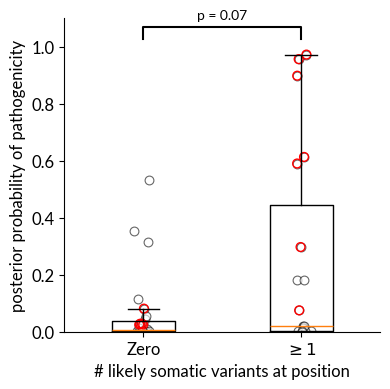

In [35]:
fig, ax = plt.subplots(1, 1, figsize=[4, 4]) # originally 7, 5

# 1 or more somatic variants
data = [somatic_paths_not_1plus_ukb, somatic_paths_1plus]
data_dbd = [somatic_paths_not_1plus_ukb_dbd, somatic_paths_1plus_dbd]
labels = ['Zero', r'$\geq1$']
bp = ax.boxplot(data, labels=labels, sym='', widths=0.4)#, patch_artist=True, widths=0.6)
# Optional: make jitter reproducible
rng = np.random.default_rng(42)

# Add jittered points
for i, (array, array_dbd) in enumerate(zip(data, data_dbd)):
    array = np.asarray(array)
    array_dbd = np.asarray(array_dbd)

    # Create jittered x-coordinates
    x_position = i + 1  # boxplot positions start at 1
    x_jitter = rng.normal(x_position, 0.03, size=len(array))

    # Plot all points (white with black edge)
    ax.scatter(
        x_jitter, array,
        alpha=0.6, s=40,
        color='white', edgecolors='black', linewidths=0.8
    )

    # Highlight DBD subset in red
    if len(array_dbd) > 0:
        # Match values in array_dbd to array
        # (if you’re worried about float precision, you can use np.isclose instead)
        mask = np.isin(array, array_dbd)

        ax.scatter(
            x_jitter[mask], array[mask],
            s=40,
            facecolors='none',  # hollow red circles
            edgecolors='red'
        )


for i, (data1, data2) in enumerate([[data[0], data[1]]]):


    u_stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    print(u_stat, p_value)

    # Add bracket and p-value
    y_max = max([max(d) for d in data])
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    bracket_height = y_max + 0.05 * y_range

    # Draw bracket
    ax.plot([2*i+1, 2*i+1, 2*i+2, 2*i+2],
            [bracket_height, bracket_height + 0.04*y_range,
             bracket_height + 0.04*y_range, bracket_height],
            'k-', linewidth=1.5)

    # Add p-value text
    if p_value < 0.001:
        p_text = 'p < 0.001'
    elif p_value < 0.02:
        p_text = f'p = {p_value:.3f}'
    else:
        p_text = f'p = {p_value:.2f}'

    ax.text(1.5+2*i, bracket_height + 0.06*y_range, p_text,
            ha='center', va='bottom')#, fontsize=12)


ax.set_ylabel('posterior probability of pathogenicity', fontsize=12)
ax.set_xlabel('# likely somatic variants at position', fontsize=12)
ax.tick_params('both', labelsize=12)
#ax.vlines(2.5, 0, 1.1, ls='dashed', color='k', lw=1)
ax.set_ylim(0, 1.1)
plt.tight_layout()
#plt.savefig('TP53_manuscript/figures/MNE_variants_pathogenicity_fullgene_only.pdf')
plt.show()